In [20]:
import scanpy as sc
from pathlib import Path
from matplotlib.collections import PathCollection
import matplotlib.pyplot as plt
import datashader as ds
import datashader.transfer_functions as tf
import colorcet as cc
from adjustText import adjust_text
import pandas as pd
import numpy as np
import matplotlib.patheffects as pe
import matplotlib as mpl

In [2]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "figures/Quality Control"
UMAP_DF_DIR = PROJECT_ROOT / "datasets/UMAP"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
UMAP_DF_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
adata = sc.read_h5ad(PROJECT_ROOT / 'AIDA2.h5ad')

# Quality Control

In [10]:
#https://scanpy.scverse.org/en/stable/tutorials/basics/clustering.html

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
adata.obs["pMito_percent"] = adata.obs["pMito"] * 100

In [11]:
import sys

print(sys.version)

3.14.6 | packaged by Anaconda, Inc. | (main, Jun 18 2026, 21:18:42) [MSC v.1942 64 bit (AMD64)]


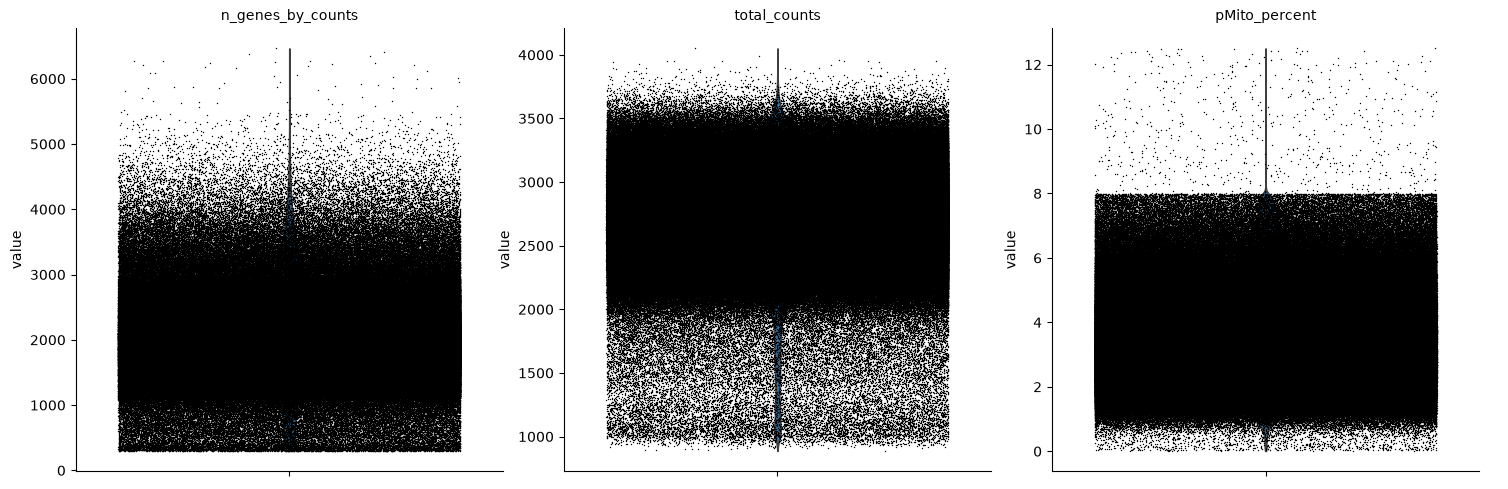

In [15]:
qc = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pMito_percent"],
    jitter=0.4,
    multi_panel=True,
    stripplot=True,
    show=False
)

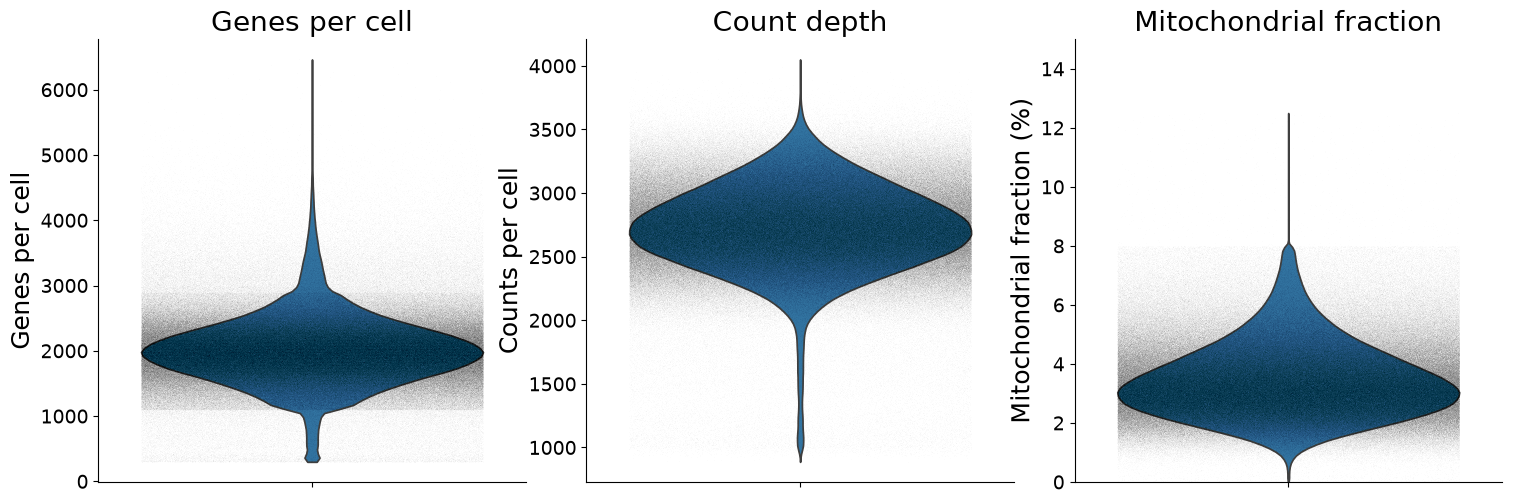

In [21]:
vars = ["n_genes_by_counts", "total_counts", "pMito_percent"]

for ax, var in zip(qc.axes.flatten(), vars):
    if var == "pMito_percent":
        ax.set_ylim(0, 15)

#Modify alpha for points
for ax in qc.axes.flatten():
    for coll in ax.collections:
        if isinstance(coll, PathCollection):
            if hasattr(coll, "get_offsets") and len(coll.get_offsets()) > 0:
                coll.set_alpha(0.0137254)

#y-axis labels
labels = ["Genes per cell", "Counts per cell", "Mitochondrial fraction (%)"]

for ax, label in zip(qc.axes.flatten(), labels):
    ax.set_ylabel(label)
    ax.set_xlabel("")

titles = ["Genes per cell", "Count depth", "Mitochondrial fraction"]

for ax, title in zip(qc.axes.flatten(), titles):
    ax.set_title(title)

for ax, title, label in zip(qc.axes.flatten(), titles, labels):
    ax.set_title(title, fontsize=20)   
    ax.set_ylabel(label, fontsize=18)       

for ax in qc.axes.flatten():
    ax.tick_params(axis='both', labelsize=14)
    
qc.fig.savefig(OUTPUT_DIR / "qc_violin.png", dpi=300, bbox_inches="tight")
display(qc.fig)
plt.close(qc.fig)

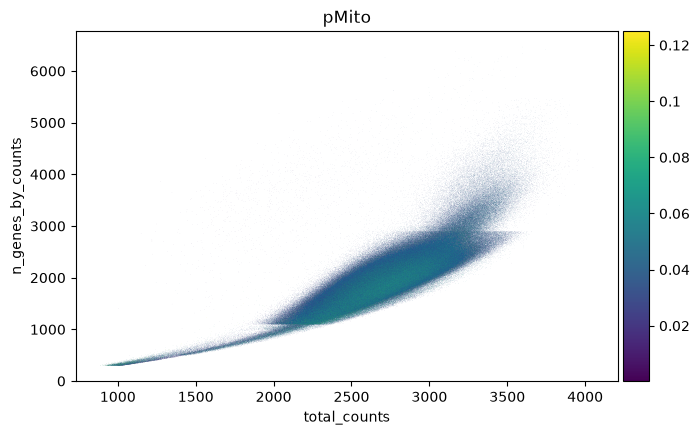

In [22]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pMito")

# Single cell Analysis

In [4]:
umap_X = adata.obsm['X_umap']

ptgs2 = "ENSG00000073756"
ptgs1 = "ENSG00000095303"

ptgs2_idx = adata.var_names.get_loc(ptgs2)
ptgs1_idx = adata.var_names.get_loc(ptgs1)
log1p_ptgs2 = adata.X[:, ptgs2_idx]
log1p_ptgs2 = log1p_ptgs2.toarray().ravel()
log1p_ptgs1 = adata.X[:, ptgs1_idx]
log1p_ptgs1 = log1p_ptgs1.toarray().ravel()
sex = adata.obs["sex"].to_numpy()
donor_id = adata.obs['donor_id'].to_numpy()

In [7]:
df_umap = pd.DataFrame(umap_X, columns=["X", "Y"])
df_umap["cell_type"] = adata.obs['Annotation_Level3'].to_numpy()
df_umap["cell_type_level2"] = adata.obs['Annotation_Level2'].to_numpy()
df_umap["ptgs2_log1p"] = log1p_ptgs2
df_umap["ptgs1_log1p"] = log1p_ptgs1
df_umap["sex"] = sex
df_umap["donor_id"] = donor_id
df_umap.to_csv(UMAP_DF_DIR / "umap_X.txt", sep="\t", index=False)

In [10]:
#only for later use so that the full AnnData object does not need to be reloaded in memory for UMAP projections

df_umap = pd.read_csv(UMAP_DF_DIR / "umap_X.txt", sep="\t")

df_umap["X"] = df_umap["X"].astype("float32")
df_umap["Y"] = df_umap["Y"].astype("float32")
df_umap["ptgs2_log1p"] = df_umap["ptgs2_log1p"].astype("float32")
df_umap["ptgs1_log1p"] = df_umap["ptgs1_log1p"].astype("float32")
df_umap["cell_type"] = df_umap["cell_type"].astype("category")
df_umap["cell_type_level2"] = df_umap["cell_type_level2"].astype("category")
df_umap["sex"] = df_umap["sex"].astype("category")

### UMAP projections

Index(['B', 'CD14+_Monocyte', 'CD16+_Monocyte', 'CD16+_NK', 'CD34_HSPC',
       'CD4+_T', 'CD4+_T_cm', 'CD4+_T_cyt', 'CD4+_T_em', 'CD4+_T_naive',
       'CD56+_NK', 'CD8+_T', 'CD8+_T_GZMBhi', 'CD8+_T_GZMKhi', 'CD8+_T_naive',
       'DC_SIGLEC6hi', 'ILC', 'MAIT', 'Myeloid', 'NK', 'Plasma_Cell',
       'Platelet', 'T', 'Treg', 'atypical_B', 'cDC1', 'cDC2', 'dnT',
       'gdT_GZMBhi', 'gdT_GZMKhi', 'memory_B', 'memory_B_IGHMhi',
       'memory_B_IGHMlo', 'naive_B', 'pDC'],
      dtype='object')


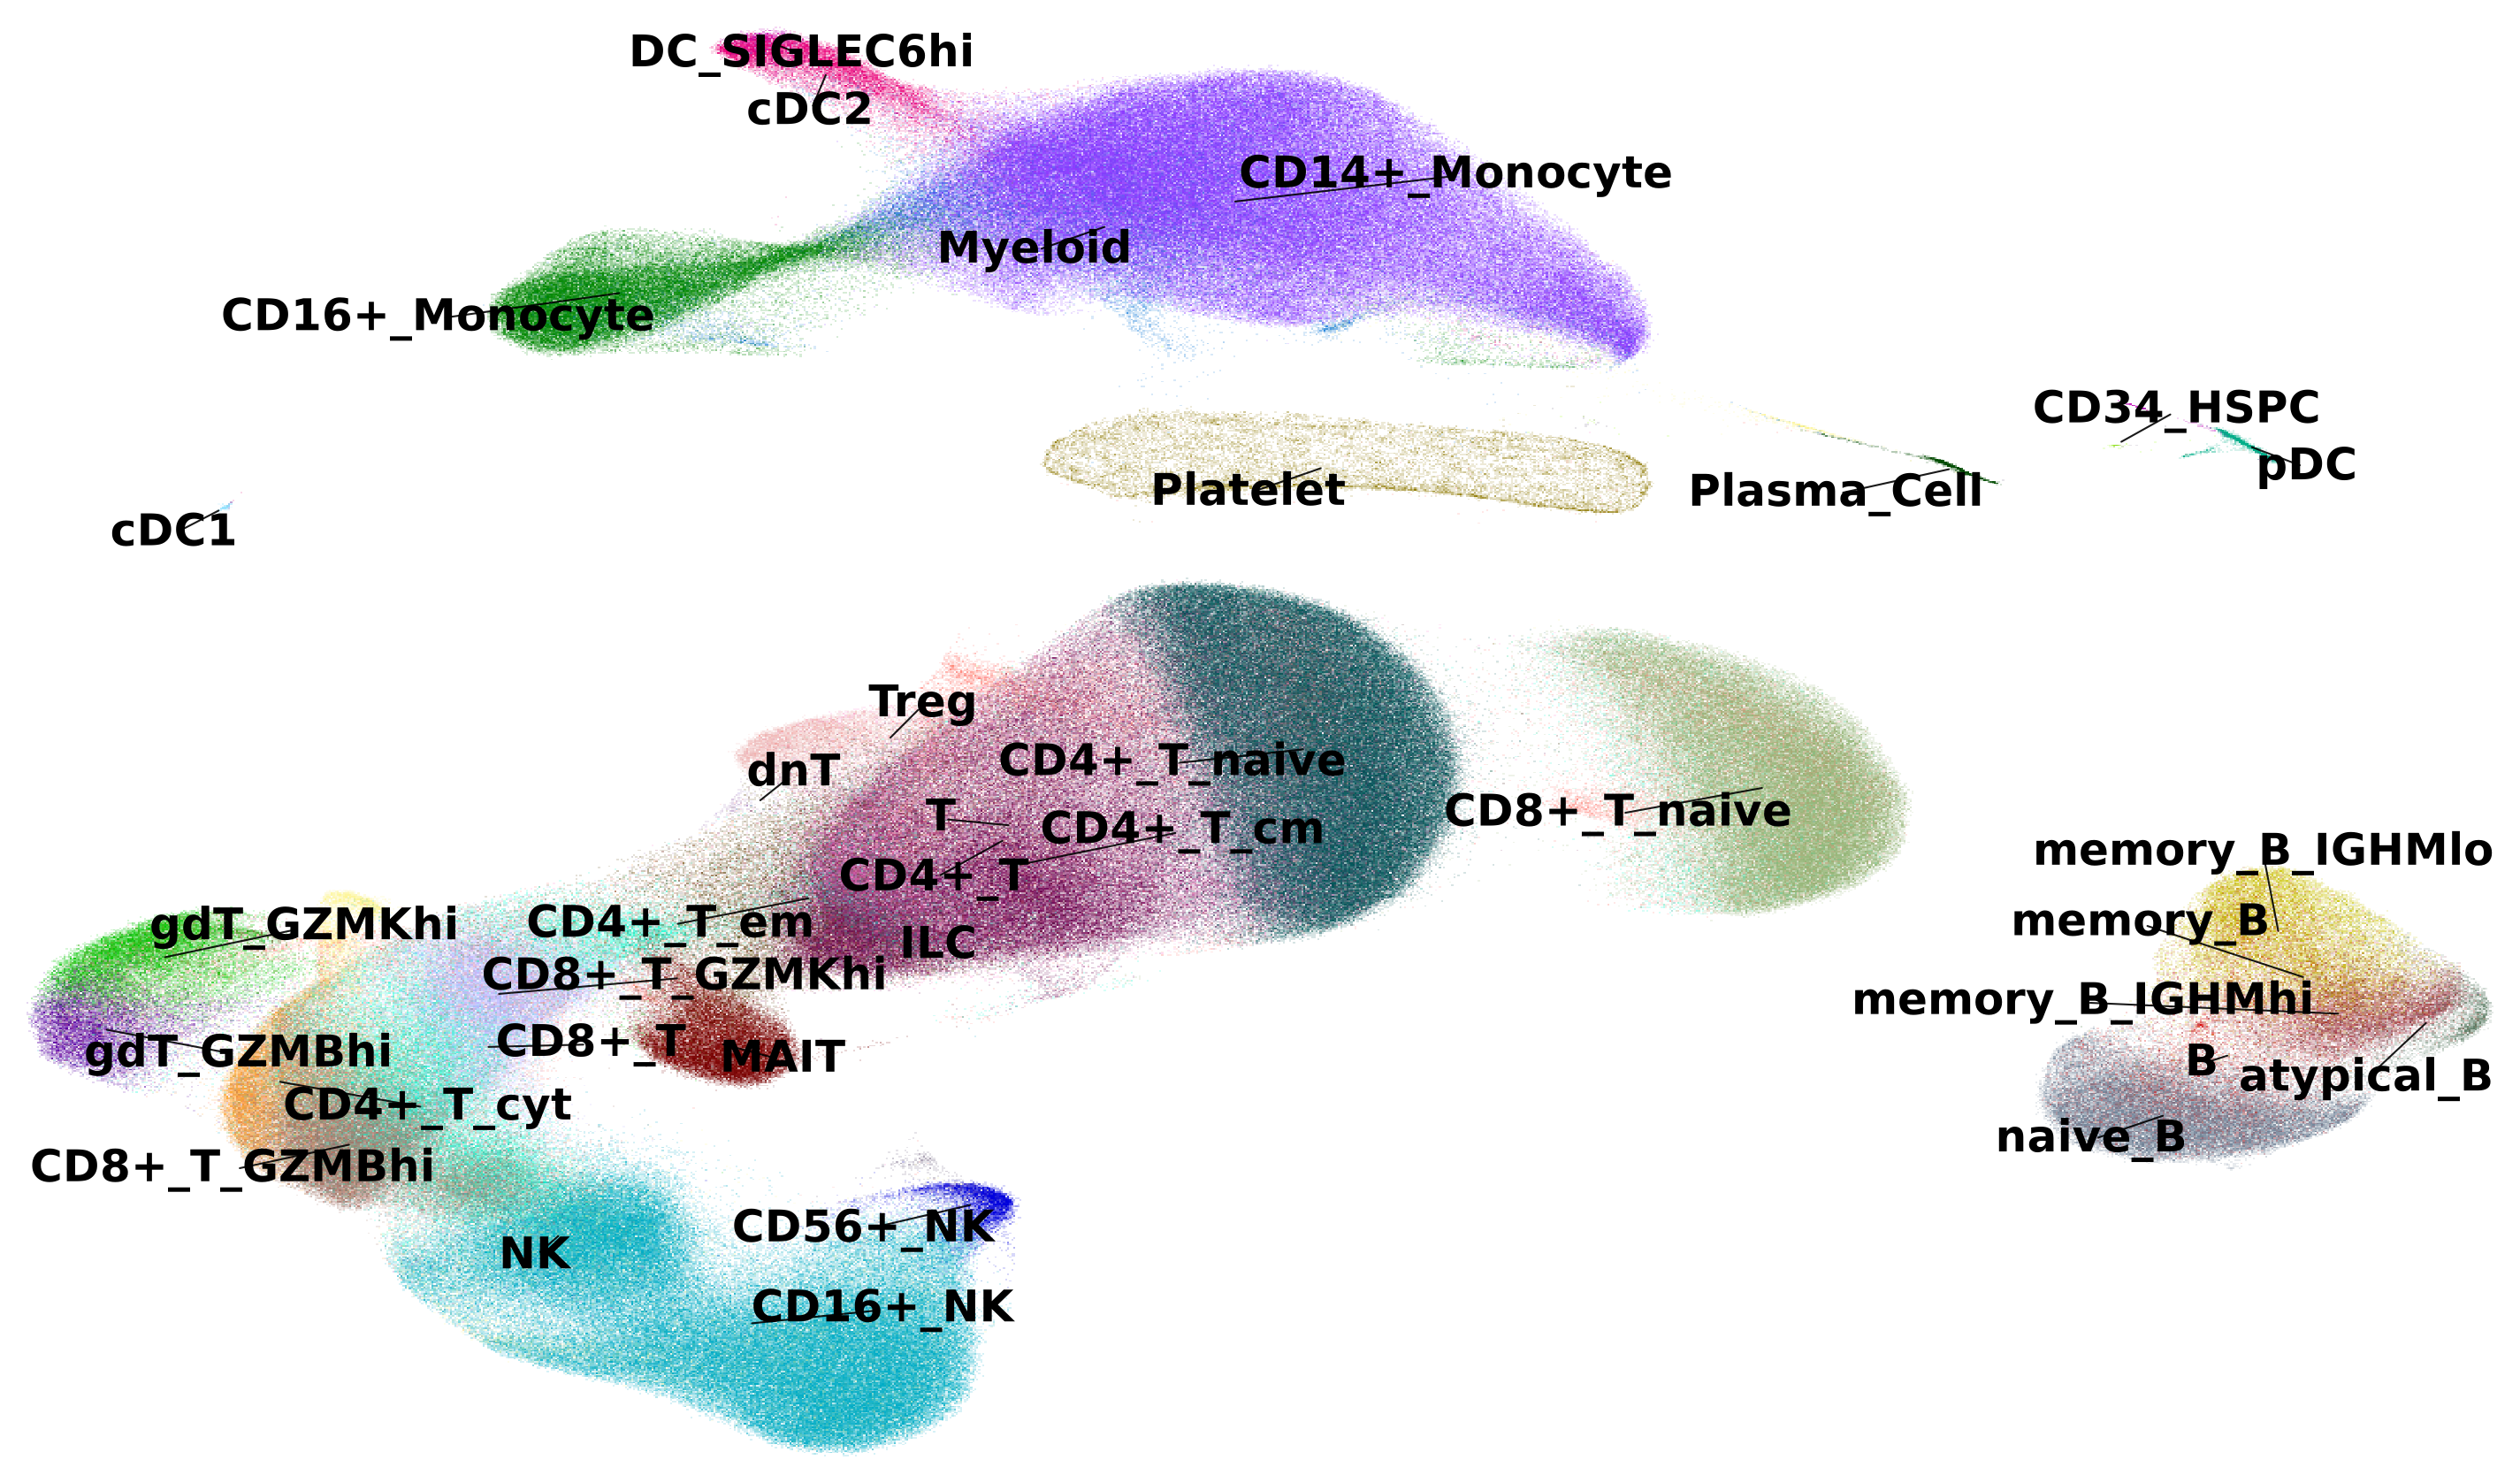

In [13]:
# prints all cell types
cats = df_umap["cell_type"].cat.categories
print(cats)

colors = cc.glasbey[:len(cats)] 
color_key = dict(zip(cats, colors))

#UMAP projection with cell anotations
W, H = 1200, 900
cvs = ds.Canvas(plot_width=W, plot_height=H)
agg = cvs.points(df_umap, x="X", y="Y", agg=ds.count_cat("cell_type"))
img = tf.shade(agg, color_key=color_key, how="eq_hist")
img = tf.set_background(img, "white")
img

dpi = 300
figsize = (12,7)

label_df = (df_umap.groupby("cell_type", observed=True)[["X", "Y"]].median().reset_index())

x_min, x_max = df_umap["X"].min(), df_umap["X"].max()
y_min, y_max = df_umap["Y"].min(), df_umap["Y"].max()

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.imshow(
    img.to_pil(),
    extent=[x_min, x_max, y_min, y_max],
    interpolation="nearest",
    aspect="auto"
)
ax.set_axis_off()

texts = []
for _, r in label_df.iterrows():
    t = ax.text(
        r["X"], r["Y"],
        r["cell_type"],
        fontsize=12,
        weight="bold",
        ha="center",
        va="center",
        color="black"
    )
    texts.append(t)

#annotation
adjust_text(
    texts,
    ax=ax,
    only_move={"text": "xy"},          
    expand_text=(1.2, 1.2),           
    expand_points=(1.2, 1.2),         
    force_text=(0.5, 0.5),           
    force_points=(0.2, 0.2),
    lim=200,                        
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.9)
)

plt.savefig(OUTPUT_DIR / "umap_cell_types.png",dpi=dpi, bbox_inches="tight", pad_inches=0.3)
plt.show()

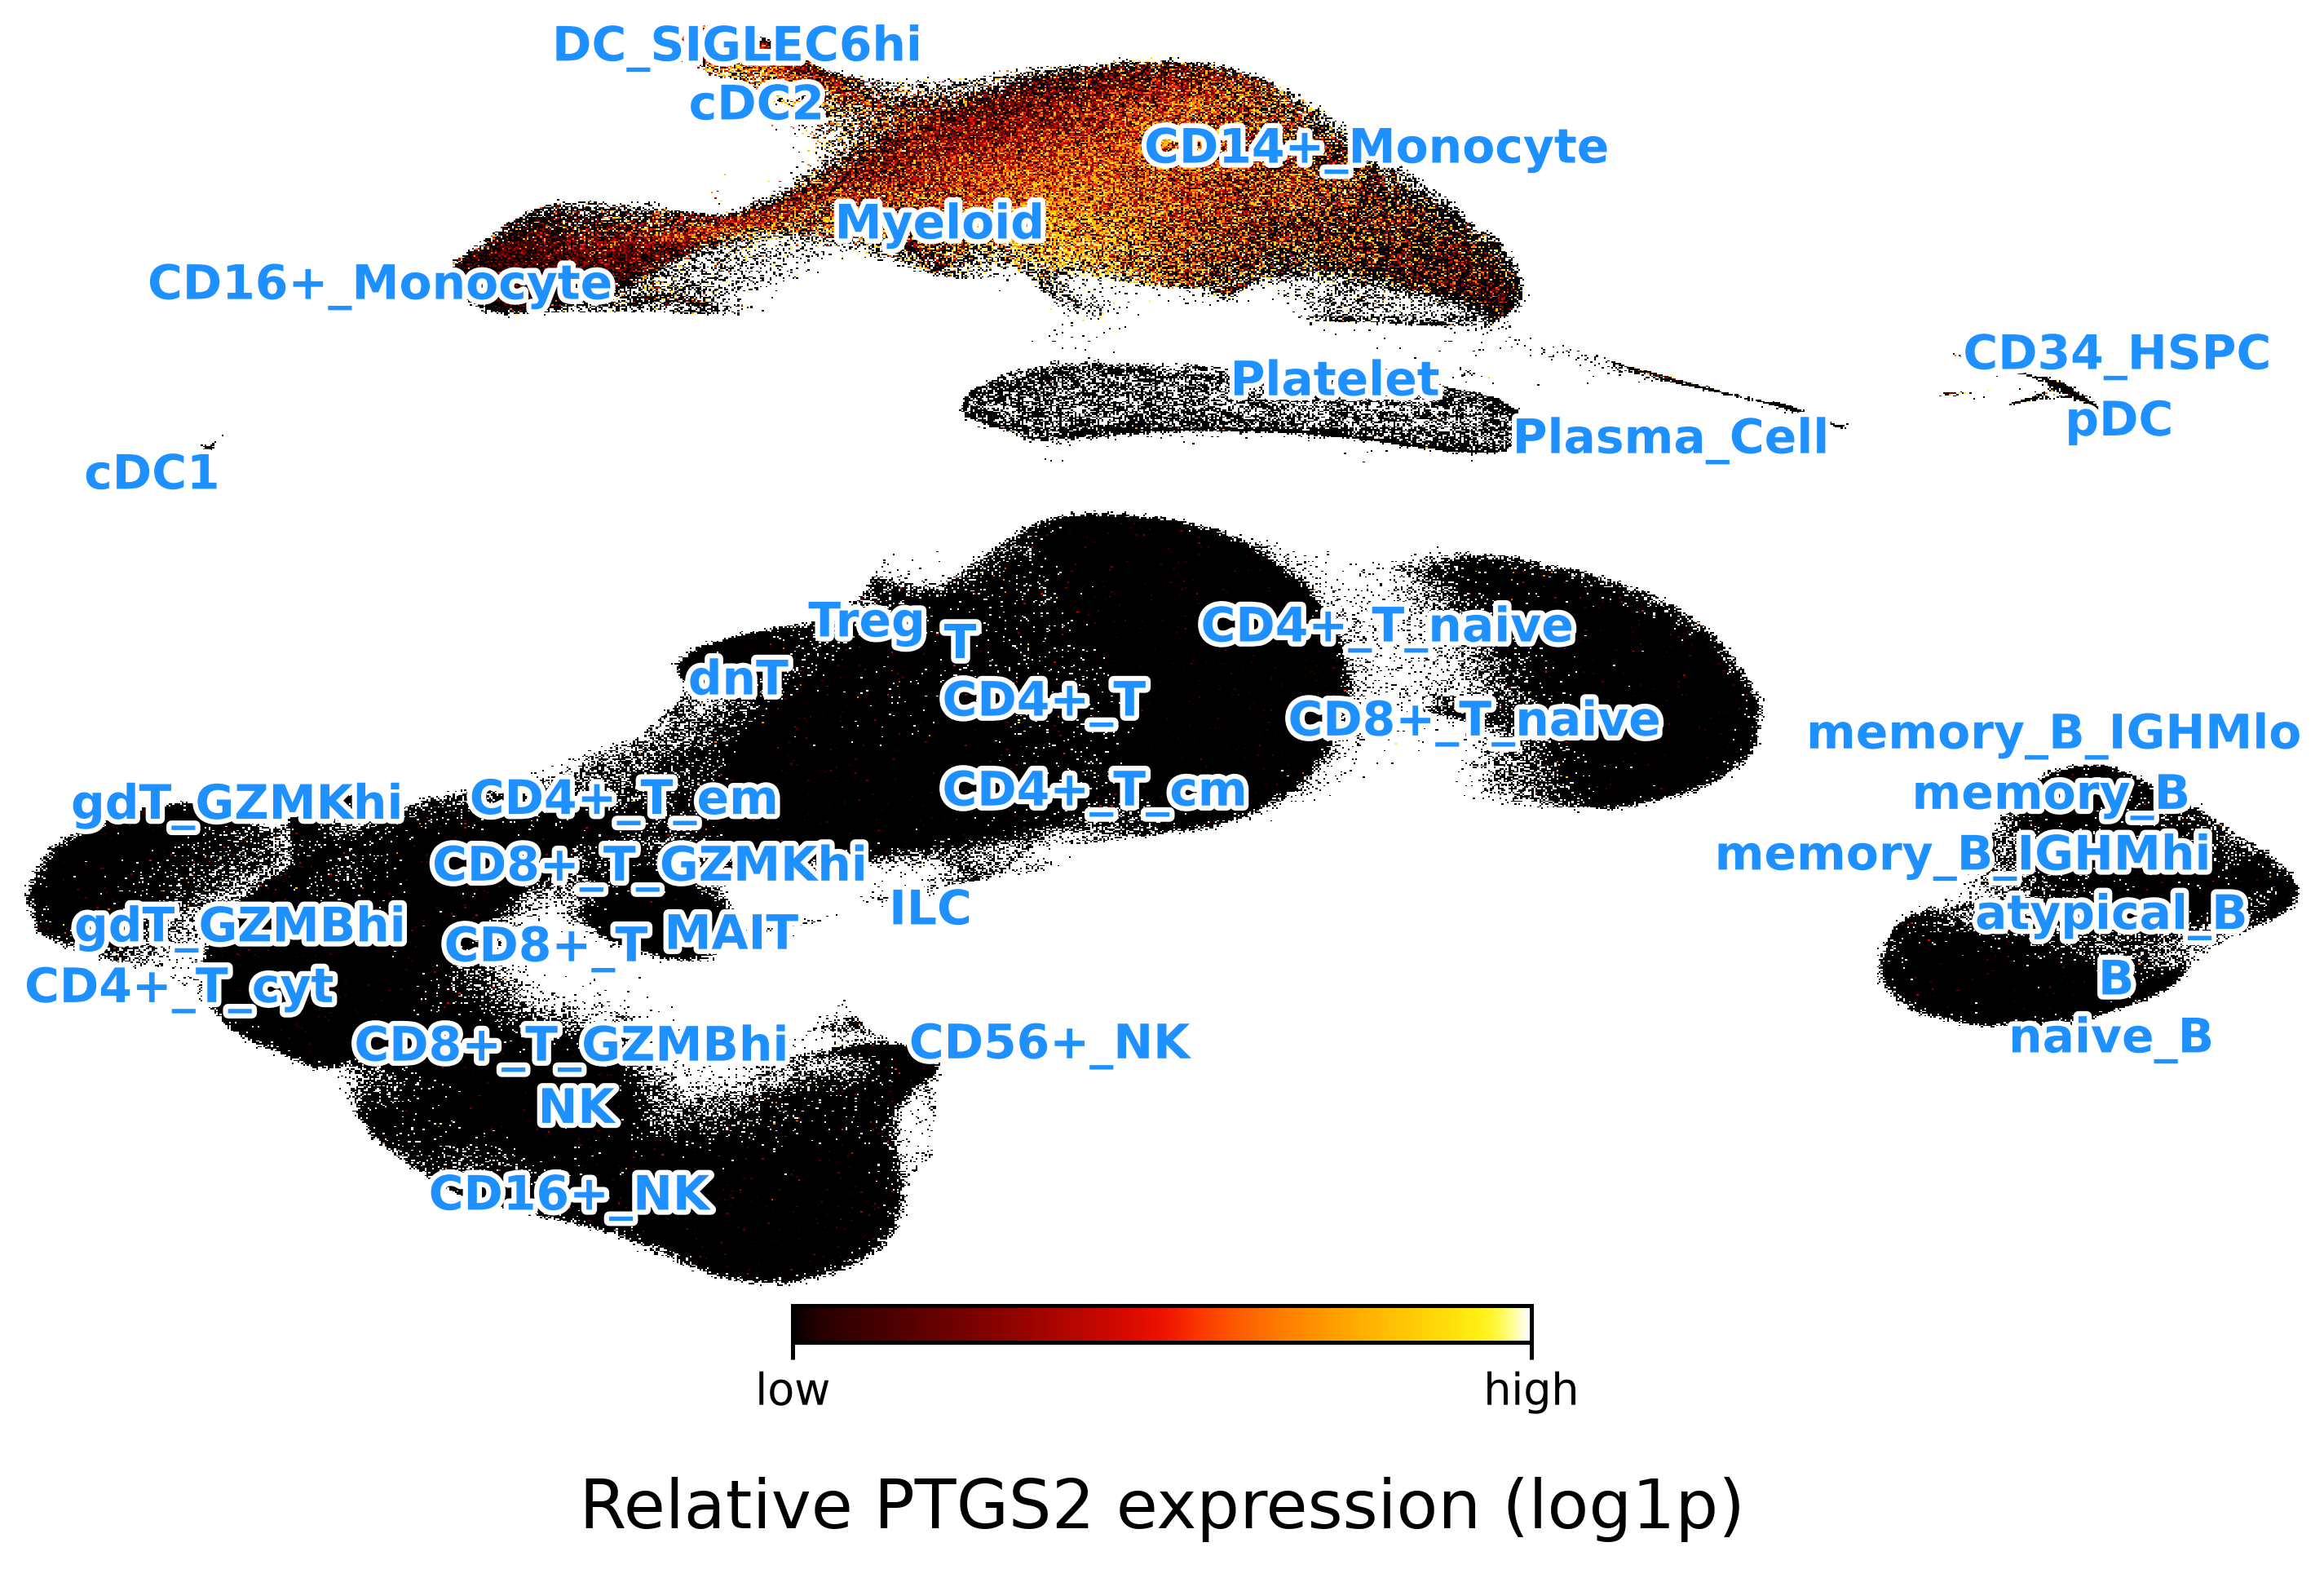

In [21]:
cvs = ds.Canvas(plot_width=W, plot_height=H)
agg = cvs.points(df_umap, "X", "Y", agg=ds.mean("ptgs2_log1p"))
img = tf.shade(agg, cmap=cc.fire, how="eq_hist")
img = tf.set_background(img, "white")
img

dpi = 300
figsize = (12,7)

vals = agg.values
vmin = np.nanpercentile(vals, 1)
vmax = np.nanpercentile(vals, 99)
x_min, x_max = df_umap["X"].min(), df_umap["X"].max()
y_min, y_max = df_umap["Y"].min(), df_umap["Y"].max()

cell_types = df_umap["cell_type"].astype("category").cat.categories
celltype_colors = dict(zip(cell_types, cc.glasbey[:len(cell_types)]))

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
ax.set_position([0, 0, 1, 1])
im = ax.imshow(img.to_pil(),extent=[x_min, x_max, y_min, y_max],interpolation="nearest",aspect="auto")
ax.set_axis_off()

cmap = mpl.colors.ListedColormap(cc.fire)
norm = mpl.colors.Normalize(vmin=df_umap["ptgs2_log1p"].min(), vmax=df_umap["ptgs2_log1p"].max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm,ax=ax,fraction=0.028, pad=0.015,shrink=0.82,orientation="horizontal")
cbar.set_ticks([df_umap["ptgs2_log1p"].min(),df_umap["ptgs2_log1p"].max()])
cbar.ax.tick_params(labelsize=13,width=1.2,length=5)
cbar.outline.set_linewidth(1.2)
cbar.set_label("Relative PTGS2 expression (log1p)",fontsize=20,labelpad=18)
cbar.set_ticklabels(["low", "high"])

texts = []
for _, r in label_df.iterrows():
    t = ax.text(
        r["X"], r["Y"],
        r["cell_type"],
        fontsize=14,
        weight="bold",
        ha="center",
        va="center",
        color = "dodgerblue",
        path_effects=[
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ]
    )
    texts.append(t)

adjust_text(
    texts,
    ax=ax,
    only_move={"text": "xy"},         
    expand_text=(1.2, 1.2),           
    expand_points=(1.2, 1.2),     
    force_text=(0.5, 0.5),          
    force_points=(0.2, 0.2),
    lim=200,                          
)

plt.savefig(OUTPUT_DIR / "umap_ptgs2_heat_labeled.png",dpi=300,bbox_inches="tight",pad_inches=0.3)
plt.show()

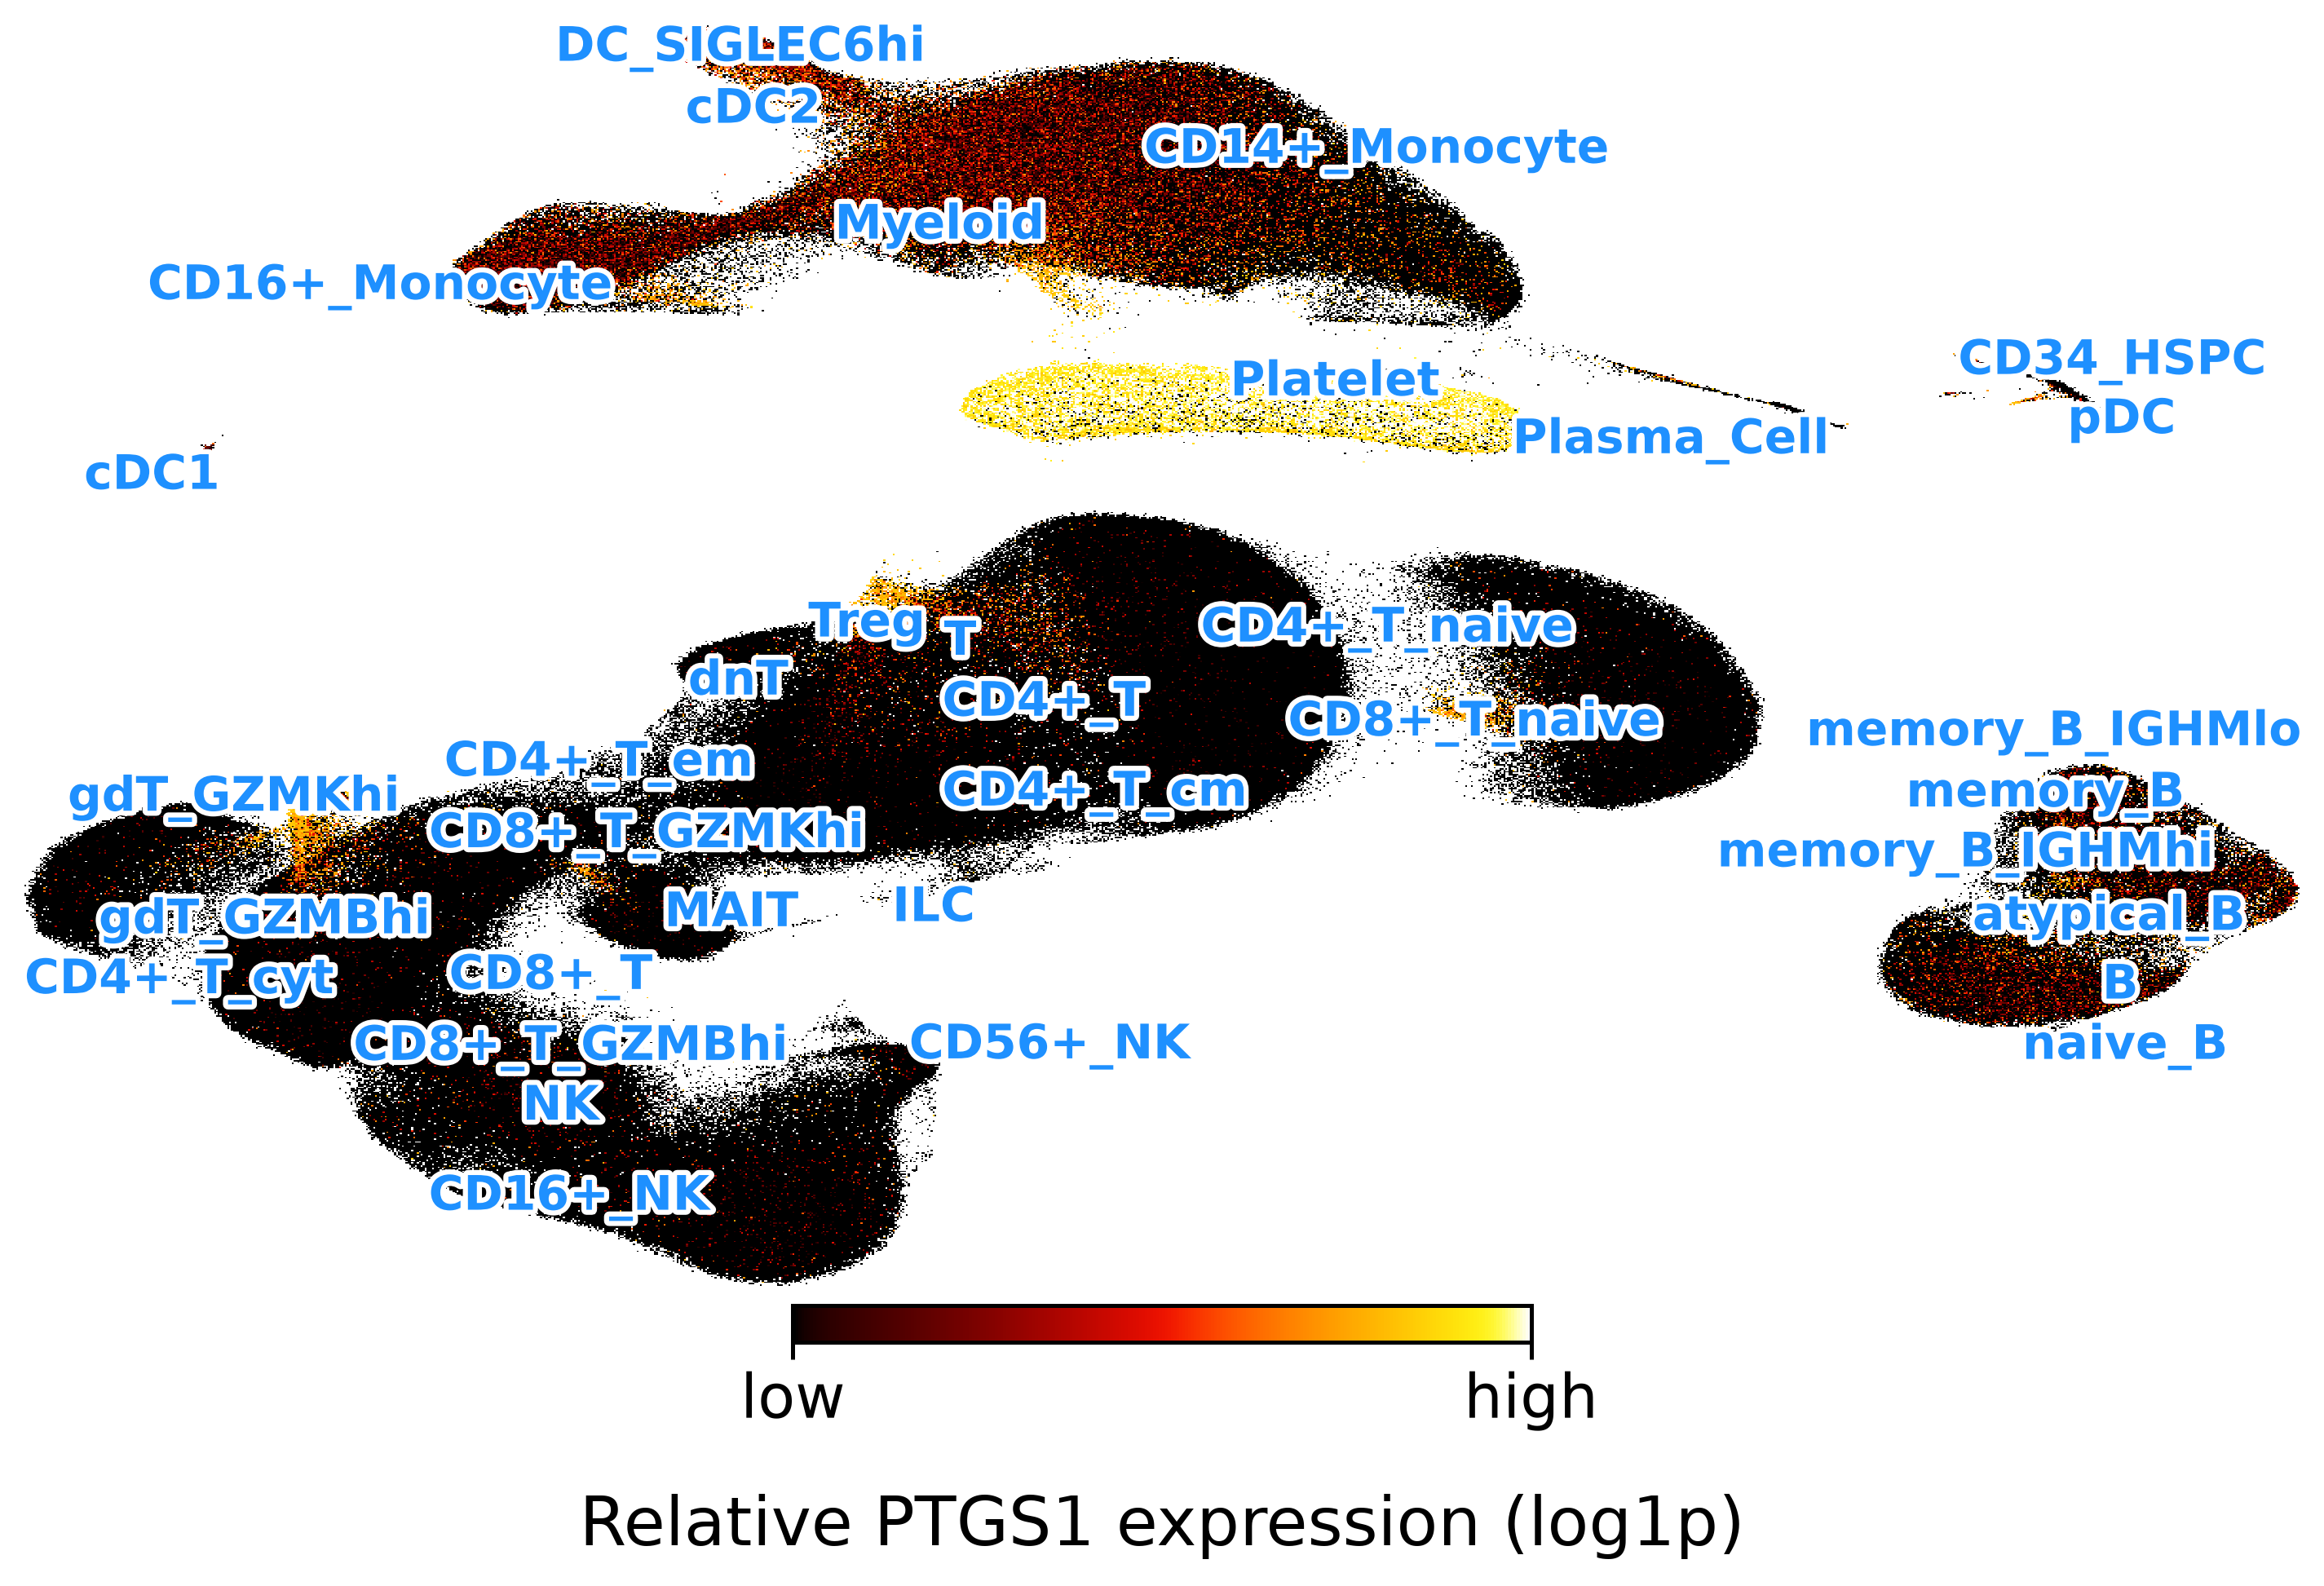

In [22]:
cvs = ds.Canvas(plot_width=W, plot_height=H)
agg = cvs.points(df_umap, "X", "Y", agg=ds.mean("ptgs1_log1p"))
img = tf.shade(agg, cmap=cc.fire, how="eq_hist")
img = tf.set_background(img, "white")
img

vals = agg.values
vmin = np.nanpercentile(vals,1)
vmax = np.nanpercentile(vals,99)
x_min, x_max = df_umap["X"].min(), df_umap["X"].max()
y_min, y_max = df_umap["Y"].min(), df_umap["Y"].max()

cell_types = df_umap["cell_type"].astype("category").cat.categories
celltype_colors = dict(zip(cell_types, cc.glasbey[:len(cell_types)]))

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
ax.set_position([0, 0, 1, 1])
ax.imshow(img.to_pil(),extent=[x_min, x_max, y_min, y_max],interpolation="nearest",aspect="auto")
ax.set_axis_off()

cmap = mpl.colors.ListedColormap(cc.fire)
norm = mpl.colors.Normalize(vmin=df_umap["ptgs1_log1p"].min(), vmax=df_umap["ptgs1_log1p"].max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm,ax=ax,fraction=0.028, pad=0.015,shrink=0.82, orientation="horizontal")
cbar.set_ticks([df_umap["ptgs1_log1p"].min(), df_umap["ptgs1_log1p"].max()])
cbar.ax.tick_params(labelsize=13,width=1.2,length=5)
cbar.outline.set_linewidth(1.2)
cbar.set_label("Relative PTGS1 expression (log1p)",fontsize=20,labelpad=18)
cbar.set_ticklabels(["low", "high"], fontsize=18)

texts = []
for _, r in label_df.iterrows():
    t = ax.text(
        r["X"], r["Y"],
        r["cell_type"],
        fontsize=14,
        weight="bold",
        ha="center",
        va="center",
        color = "dodgerblue",
        path_effects=[
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ]
    )
    texts.append(t)

adjust_text(
    texts,
    ax=ax,
    only_move={"text": "xy"},  
    expand_text=(1.2, 1.2),           
    expand_points=(1.2, 1.2),         
    force_text=(0.5, 0.5),             
    force_points=(0.2, 0.2),
    lim=200,                           
)

plt.savefig(OUTPUT_DIR / "umap_ptgs1_heat_labeled.png",dpi=300,bbox_inches="tight",pad_inches=0.3)
plt.show()